In [ ]:
import scanpy as sc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
%load_ext autoreload
%autoreload 2

from gfm import GFM
from gfm.helpers import get_pert_graph_info, add_pert_graph_metrics, combine_results

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8

In [ ]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## combined all datasets

In [ ]:
result_list = []
for dataset in  ['replogle_k562', 'replogle_rpe1', 'nadig_jurkat', 'nadig_hepg2']:
    adata = sc.read_h5ad(f"../data/preprocessed_{dataset}.h5ad")

    for split in [1, 2, 3]:
        split_path = f"../data/splits/{dataset}_single_{split}_0.75.pkl"
        gfm = GFM(
            adata=adata,
            split_dict_path=split_path,
            output_dir=f"../data/gfm/{dataset}/split_{split}/",
            device=device
        )
        gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", graph_dir="../data/gears/")
        result_dict = {
            'GFM': [f"../data/gfm/{dataset}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv"],
            'Perturb train': [f"../data/pert_train/{dataset}/results_test_{split}.csv"]
        }
        result_combined = combine_results(result_dict, baseline_model="Perturb train")
        pert_graph_info = get_pert_graph_info(gfm, gfm.split.split_dict['test'])
        add_pert_graph_metrics(result_combined, pert_graph_info)
        result_combined['split'] = split
        result_combined['dataset'] = dataset
        result_list.append(result_combined)

result_all = pd.concat(result_list, ignore_index=True)

In [ ]:
result_all.head()

,mse,pearson,spearman,mmd,pearson_delta,w2d,e_distance,condition,split,model,n_source_nodes_trained,train_node_ratio,max_sim,median_sim,dataset
0,0.003571,-0.000793,-0.001504,0.115758,0.148872,-0.340576,0.385371,DDB1+ctrl,1,GFM,190,0.218894,0.451668,0.240582,replogle_k562
1,-0.006456,0.002063,0.003008,0.137180,0.412137,-0.409971,0.352421,NBAS+ctrl,1,GFM,136,0.168734,0.546345,0.287388,replogle_k562
2,-0.024105,0.004407,0.009023,0.158980,0.685720,-0.427338,0.241801,PDRG1+ctrl,1,GFM,146,0.191853,0.648091,0.171451,replogle_k562
3,0.103224,-0.002690,0.001504,0.232570,0.009137,0.143781,1.300222,RUVBL1+ctrl,1,GFM,234,0.271462,0.774607,0.280891,replogle_k562
4,-0.064218,0.012379,0.025564,0.205007,0.726342,-0.552230,0.433972,TNPO3+ctrl,1,GFM,237,0.205195,0.254065,0.065278,replogle_k562


In [ ]:
result_all.to_csv(f"../data/final_plots_data/correlation_dotplot_graph_metrics_new.csv", index=False)

In [ ]:
result_all = pd.read_csv(f"../data/final_plots_data/correlation_dotplot_graph_metrics_new.csv")

In [ ]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_cols = ['n_source_nodes_trained', 'train_node_ratio', 'max_sim', 'median_sim']
y_cols = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']

x_labels = {
    'n_source_nodes_trained': 'Train neighbors',
    'train_node_ratio': 'Train-neighbor fraction',
    'max_sim': 'Max similarity',
    'median_sim': 'Median similarity',
}

y_labels = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson r',
        'pearson_delta': 'Pearson Delta',
        'spearman': 'Δ Spearman rho',
        'mmd': 'Δ MMD',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance'
    }

def fisher_mean(rhos):
    rhos = np.asarray(rhos)
    rhos = np.clip(rhos, -0.999999, 0.999999)
    return np.tanh(np.mean(np.arctanh(rhos)))

In [ ]:
corr_rows = []

for (dataset, split), group in result_all.groupby(['dataset', 'split']):
    for x_col in x_cols:
        for y_col in y_cols:
            valid = group[[x_col, y_col]].dropna()

            if len(valid) < 3:
                continue

            rho, p_value = spearmanr(valid[x_col], valid[y_col])

            corr_rows.append({
                'dataset': dataset,
                'split': split,
                'x_col': x_col,
                'y_col': y_col,
                'rho': rho,
                'p_value': p_value,
            })

corr_by_split = pd.DataFrame(corr_rows)

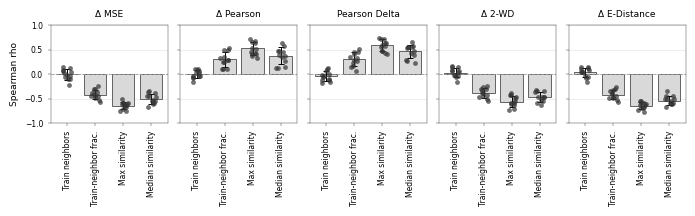

In [ ]:
summary = (
    corr_by_split
    .groupby(['y_col', 'x_col'])
    .agg(
        mean_rho=('rho', fisher_mean),
        sd_rho=('rho', 'std'),
        n=('rho', 'size'),
    )
    .reset_index()
)
summary['sd_rho'] = summary['sd_rho'].fillna(0)

fig, axes = plt.subplots(1, len(y_cols), figsize=(1.4 * len(y_cols), 2.2), sharey=True)
if len(y_cols) == 1:
    axes = [axes]

for ax, y_col in zip(axes, y_cols):
    stats = (
        summary[summary['y_col'] == y_col]
        .set_index('x_col')
        .reindex(x_cols)
        .reset_index()
    )

    subset = corr_by_split[corr_by_split['y_col'] == y_col].copy()
    subset = subset.dropna(subset=['rho', 'x_col'])

    x_positions = np.arange(len(x_cols))

    means = stats['mean_rho'].to_numpy(dtype=float)
    errs = stats['sd_rho'].to_numpy(dtype=float)

    ax.bar(
        x_positions,
        means,
        yerr=errs,
        color='0.85',
        edgecolor='0.3',
        linewidth=0.6,
        error_kw={'elinewidth': 0.7, 'capsize': 2, 'capthick': 0.7},
        zorder=2,
    )

    rng = np.random.default_rng(42)
    x_map = {name: i for i, name in enumerate(x_cols)}
    subset['x_base'] = subset['x_col'].map(x_map).astype(float)
    subset['x_jitter'] = subset['x_base'] + rng.uniform(-0.18, 0.18, len(subset))

    ax.scatter(
        subset['x_jitter'],
        subset['rho'],
        color='0.2',
        s=12,
        alpha=0.7,
        linewidth=0,
        zorder=3,
    )

    ax.axhline(0, color='0.6', linestyle='--', linewidth=0.6)
    ax.set_title(y_labels[y_col])
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([x_labels[x] for x in x_cols], rotation=90)
    ax.grid(axis='y', alpha=0.2)
    # ax.tick_params(axis='y', labelleft=True, left=False)

axes[0].set_ylabel('Spearman rho')
for ax in axes[1:]:
    ax.set_ylabel('')

# fig.suptitle('Graph Connectivity vs Prediction Performance', y=1.04)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.savefig('../data/final_plots/correlation_barplot_graph_metrics_new.pdf', dpi=300, bbox_inches='tight')
plt.show()

### example

In [ ]:
from gfm.helpers import sample_x0_from_ctrl
import scanpy as sc

def get_adata_multiple_condition_subset(adata_path_dict, condition_list):
    adata_list = []
    missing_models = []
    has_control = False
    for ((model, path), condition) in zip(adata_path_dict.items(), condition_list):
        adata = sc.read_h5ad(path, backed='r')
        
        if model in ["Truth", "Truth sim cond"]:
            filt = adata.obs['condition'] == condition

            if not has_control:
                x0 = sample_x0_from_ctrl(adata, sum(filt))
                adata_ctrl = sc.AnnData(X=x0, var=adata.var)
                adata_ctrl.obs['condition'] = 'ctrl'
                adata_ctrl.obs['model'] = 'Control'
                adata_list.append(adata_ctrl)
                has_control = True
            uns_rank_genes_groups_list = adata.uns['rank_genes_groups_list']

            adata_subset = adata[filt].to_memory()
            if adata_subset.n_obs == 0:
                missing_models.append(model)
                continue
            adata_subset.obs['model'] = model
            adata_list.append(adata_subset)
        else:
            pert = '+'.join([pert_gene for pert_gene in condition.split('+') if pert_gene != 'ctrl'])
            filt = adata.obs['condition'] == pert
            adata_subset = adata[filt].to_memory()
            if adata_subset.n_obs == 0:
                print(f"Warning: No cells found for model '{model}' under condition '{condition}' (looking for perturbation '{pert}'). Skipping this model.")
                missing_models.append(model)
                continue
            adata_subset.obs['model'] = model
            adata_list.append(adata_subset)

    if not adata_list:
        raise ValueError(
            f"No cells found for condition '{condition}'. Checked models: {', '.join(adata_path_dict.keys())}."
        )

    adata = sc.concat(adata_list, axis=0)
    adata.obs_names_make_unique()
    adata.uns['rank_genes_groups_list'] = uns_rank_genes_groups_list

    n_pca_components = min(50, adata.n_obs - 1, adata.n_vars - 1)
    if n_pca_components < 1:
        missing_models_msg = ""
        if missing_models:
            missing_models_msg = f" Missing model subsets: {', '.join(missing_models)}."
        raise ValueError(
            f"Need at least 2 cells and 2 genes to compute PCA/UMAP for condition '{condition}', "
            f"but got {adata.n_obs} cells and {adata.n_vars} genes after concatenation.{missing_models_msg}"
        )

    sc.pp.pca(adata, n_comps=n_pca_components)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    return adata
import seaborn as sns
from matplotlib.patches import Patch

def plot_delta_expression_boxplot_model_cond(
    adata,
    condition_list,
    model_name_list,
    legend_name_list,
    top_n=10,
    palette=None,
    title=None,
    save_path=None,
    return_plot_df=False,
    figsize=(7, 2),
):
    colormap_name = "tab10"

    if palette is None:
        palette = sns.color_palette(colormap_name, n_colors=len(model_name_list))

    # first condition should be the ground truth condition
    top_genes = adata.uns["rank_genes_groups_list"][condition_list[0]][:top_n]

    plot_df_ctrl_mean = adata[adata.obs["model"] == "Control", top_genes].to_df().mean()

    plot_df_list = []
    for model_name, condition, legend in zip(model_name_list, condition_list, legend_name_list):
        if model_name == "Control":
            continue
        if model_name in ["Truth", "Truth sim cond"]:
            df = adata[
                (adata.obs["condition"] == condition) & (adata.obs["model"] == model_name), top_genes
            ].to_df()
            plot_df_norm = df - plot_df_ctrl_mean
        else:
            pert = "+".join([pert_gene for pert_gene in condition.split("+") if pert_gene != "ctrl"])
            df = adata[
                (adata.obs["condition"] == pert) & (adata.obs["model"] == model_name), top_genes
            ].to_df()
            plot_df_norm = df - plot_df_ctrl_mean

        plot_df_melted = plot_df_norm.melt(var_name="Gene", value_name="Expression")
        plot_df_melted["Model"] = legend
        plot_df_list.append(plot_df_melted)

    combined_plot_df = pd.concat(plot_df_list, ignore_index=True)
    combined_plot_df["Model"] = pd.Categorical(
        combined_plot_df["Model"], categories=legend_name_list
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=combined_plot_df,
        x="Gene",
        y="Expression",
        hue="Model",
        palette=palette,
        fill=True,
        dodge=True,
        gap=0.1,
        linewidth=0.25,
        fliersize=0.25,
        ax=ax,
        saturation=1.0,
        legend=False,
    )
    if isinstance(palette, list):
        legend_elements = [
            Patch(facecolor=palette[i], label=legend)
            for i, legend in enumerate(legend_name_list)
        ]
    else:
        legend_elements = [
            Patch(facecolor=palette[legend], label=legend) for legend in legend_name_list
        ]
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(legend_name_list),
        frameon=False,
    )
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.5)
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"Perturbed gene: {condition_list[0]}")
    ax.set_xlabel("")
    current_labels = ax.get_xticklabels()
    ax.set_xticklabels(current_labels, rotation=30, ha="right", rotation_mode="anchor")
    ax.set_ylabel("LogFC (normalized to control)")

    plt.tight_layout(rect=(0, 0.08, 1, 1))
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    if return_plot_df:
        return combined_plot_df

In [ ]:
dataset = 'replogle_rpe1'
split = 3
condition_query = 'PSMB2+ctrl'

In [ ]:
adata = sc.read_h5ad(f"../data/processed_{dataset}.h5ad", backed="r")
split_path = f"../data/gears/{dataset}/splits/{dataset}_single_{split}_0.75.pkl"
gfm = GFM(
    adata=adata,
    split_dict_path=split_path,
    output_dir=f"../data/gfm/{dataset}/split_{split}/",
    device=device
)
gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", graph_dir="../data/gears/")
result_dict = {
    'GFM': [f"../data/gfm/{dataset}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv"],
    'Perturb train': [f"../data/pert_train/{dataset}/results_test_{split}.csv"]
}

pert_graph_info = get_pert_graph_info(gfm, gfm.split.split_dict['test'])

In [ ]:
df = pd.DataFrame({"pert_list": pert_graph_info[condition_query]['pert_list'], "sim_list": pert_graph_info[condition_query]['sim_list']})
condition_sim = df.sort_values(by='sim_list', ascending=False)['pert_list'].tolist()[0]
condition_sim = f"{condition_sim}+ctrl"
sim_value = df.sort_values(by='sim_list', ascending=False)['sim_list'].tolist()[0]
print(condition_sim, sim_value)

PSMB5+ctrl 0.9649999141693115


In [ ]:
condition_list = [condition_query, condition_sim, condition_query]
adata_paths = {
    "Truth": f"../data/processed_{dataset}.h5ad",
    "Truth sim cond": f"../data/processed_{dataset}.h5ad",
    "GFM": f"../data/gfm/{dataset}/split_{split}/adata_pred_gfm_go+gwps+ppi_gat.h5ad",
}
adata = get_adata_multiple_condition_subset(adata_paths, condition_list)

/tmp/ipykernel_2071166/1139760792.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(current_labels, rotation=30, ha="right", rotation_mode="anchor")


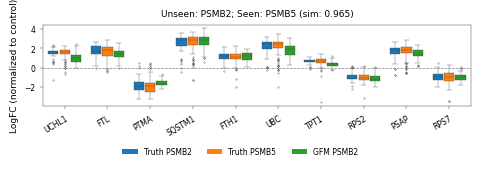

In [ ]:
model_name_list=['Truth', "Truth sim cond", 'GFM']
legend_name_list=[f'Truth {condition_list[0].split("+")[0]}', f'Truth {condition_list[1].split("+")[0]}', f'GFM {condition_list[2].split("+")[0]}']

plot_delta_expression_boxplot_model_cond(
    adata,
    condition_list,
    model_name_list,
    legend_name_list,
    title=f"Unseen: {condition_list[0].split('+')[0]}; Seen: {condition_list[1].split('+')[0]} (sim: {sim_value:.3f})",
    palette=None,
    top_n=10,
    figsize=(4.8, 1.6),
    save_path=f"../data/final_plots/{dataset}_delta_expression_boxplot_models_{condition_list[0]}_{condition_list[1]}_{split}.pdf"
)

In [ ]:
dataset = 'nadig_hepg2'
split = 1

adata = sc.read_h5ad(f"../data/processed_{dataset}.h5ad", backed="r")
split_path = f"../data/gears/{dataset}/splits/{dataset}_single_{split}_0.75.pkl"
gfm = GFM(
    adata=adata,
    split_dict_path=split_path,
    output_dir=f"../data/gfm/{dataset}/split_{split}/",
    device=device
)
gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", graph_dir="../data/gears/")
result_dict = {
    'GFM': [f"../data/gfm/{dataset}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv"],
    'Perturb train': [f"../data/pert_train/{dataset}/results_test_{split}.csv"]
}

pert_graph_info = get_pert_graph_info(gfm, gfm.split.split_dict['test'])

In [ ]:
condition_query = 'HIST1H2BN+ctrl'
df = pd.DataFrame({"pert_list": pert_graph_info[condition_query]['pert_list'], "sim_list": pert_graph_info[condition_query]['sim_list']})
condition_sim = df.sort_values(by='sim_list', ascending=False)['pert_list'].tolist()[0]
condition_sim = f"{condition_sim}+ctrl"
sim_value = df.sort_values(by='sim_list', ascending=False)['sim_list'].tolist()[0]
print(condition_sim, sim_value)

MON1A+ctrl 0.17180097103118896


In [ ]:
condition_list = [condition_query, condition_sim, condition_query]
adata_paths = {
    "Truth": f"../data/processed_{dataset}.h5ad",
    "Truth sim cond": f"../data/processed_{dataset}.h5ad",
    "GFM": f"../data/gfm/{dataset}/split_{split}/adata_pred_gfm_go+gwps+ppi_gat.h5ad",
}
adata = get_adata_multiple_condition_subset(adata_paths, condition_list)

/tmp/ipykernel_2071166/1139760792.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(current_labels, rotation=30, ha="right", rotation_mode="anchor")


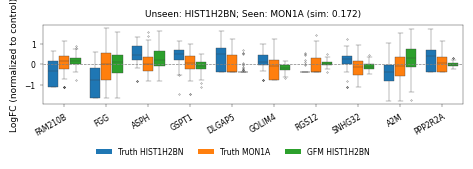

In [ ]:
model_name_list=['Truth', "Truth sim cond", 'GFM']
legend_name_list=[f'Truth {condition_list[0].split("+")[0]}', f'Truth {condition_list[1].split("+")[0]}', f'GFM {condition_list[2].split("+")[0]}']

plot_delta_expression_boxplot_model_cond(
    adata,
    condition_list,
    model_name_list,
    legend_name_list,
    title=f"Unseen: {condition_list[0].split('+')[0]}; Seen: {condition_list[1].split('+')[0]} (sim: {sim_value:.3f})",
    palette=None,
    top_n=10,
    figsize=(4.8, 1.6),
    save_path=f"../data/final_plots/{dataset}_delta_expression_boxplot_models_{condition_list[0]}_{condition_list[1]}_{split}.pdf"
)